In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [22]:
# Cargar dataset
df = pd.read_csv("vocals.csv")
df.head()


,vocal,start,end
0,e,1.116,1.206
1,o,1.306,1.386
2,a,1.466,1.516
3,e,1.606,1.656
4,e,1.776,1.866


In [6]:
df["duration"] = df["end"] - df["start"]
df.head()


,vocal,start,end,duration
0,e,1.116,1.206,0.09
1,o,1.306,1.386,0.08
2,a,1.466,1.516,0.05
3,e,1.606,1.656,0.05
4,e,1.776,1.866,0.09


In [7]:
print(df["vocal"].value_counts())


vocal
e    10
o    10
a    10
i    10
u     6
Name: count, dtype: int64


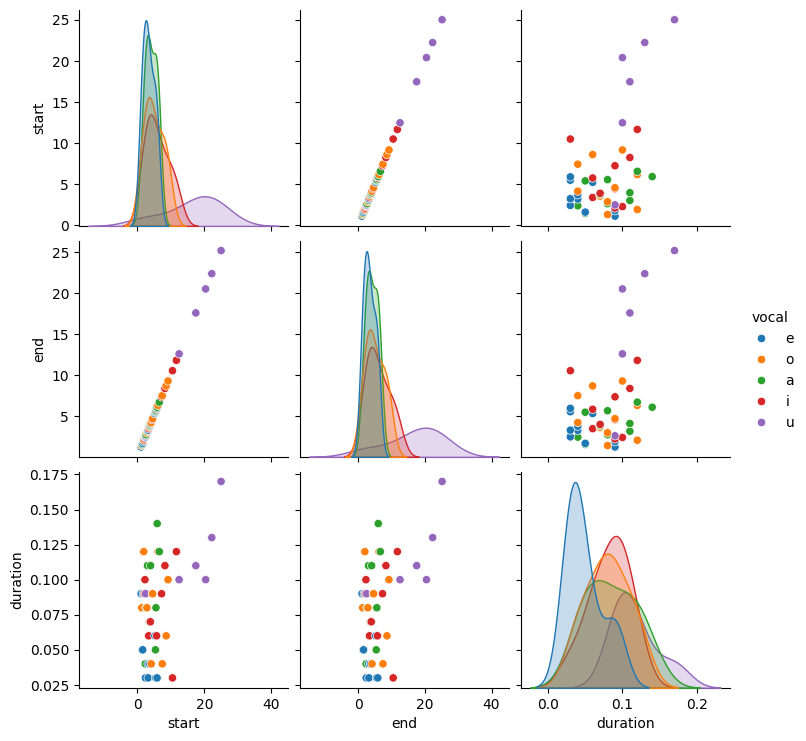

In [ ]:
sns.pairplot(df, hue="vocal", vars=["start", "end", "duration"])
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Features
X = df[["start", "end", "duration"]].values

# Labels
le = LabelEncoder()
y = le.fit_transform(df["vocal"])

print("Clases:", le.classes_)

Clases: ['a' 'e' 'i' 'o' 'u']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(32, 3) (14, 3)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

accuracy_svm = svm_model.score(X_test_scaled, y_test)
print(f"SVM Accuracy: {accuracy_svm:.4f}")


SVM Accuracy: 0.1429


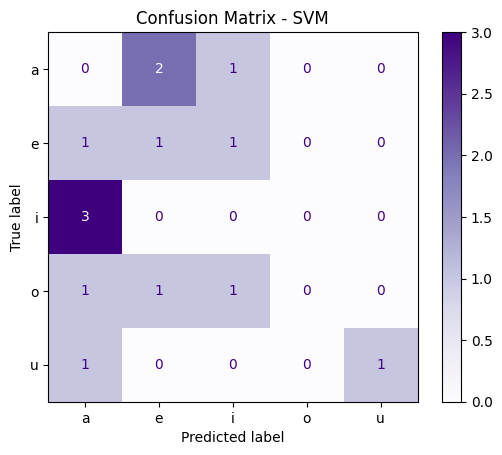

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_scaled,
    y_test,
    display_labels=le.classes_,
    cmap="Purples"
)
plt.title("Confusion Matrix - SVM")
plt.show()

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
acc_knn = knn.score(X_test_scaled, y_test)

print(f"KNN Accuracy: {acc_knn:.4f}")


KNN Accuracy: 0.2143


In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
acc_lr = lr.score(X_test_scaled, y_test)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")


Logistic Regression Accuracy: 0.2143


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
acc_dt = dt.score(X_test, y_test)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")

Decision Tree Accuracy: 0.2143


In [20]:
results = pd.DataFrame({
    "Model": ["SVM", "KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_svm, acc_knn, acc_lr, acc_dt]
}).sort_values("Accuracy", ascending=False)

results


,Model,Accuracy
1,KNN,0.214286
2,Logistic Regression,0.214286
3,Decision Tree,0.214286
0,SVM,0.142857


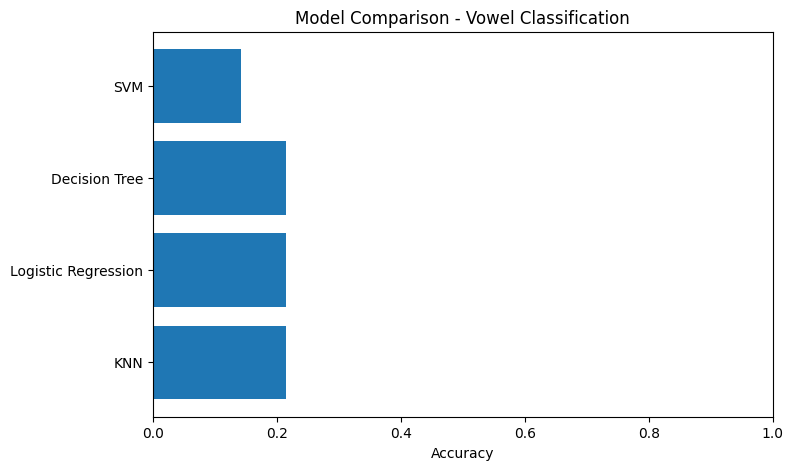

In [21]:
plt.figure(figsize=(8,5))
plt.barh(results["Model"], results["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison - Vowel Classification")
plt.xlim(0,1)
plt.show()
